In [38]:
# plot final visuals
import os
os.getcwd()
os.chdir("C:\\Users\\nathi\\Downloads\\3 Semester\\AMS\\")

plot_path = 'Plots/For Presentation/'

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from scipy.signal import find_peaks, peak_prominences
import numpy as np
from sklearn.ensemble import IsolationForest
import itertools
import numpy.typing as npt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model 
from tensorflow.keras.layers import Input, Dropout, Dense, LSTM, TimeDistributed, RepeatVector
from tensorflow.keras.optimizers import Adam
from keras import regularizers

# Choose column to detect peaks on
columns_to_predict = ['CURRENT|1', 'CURRENT|2', 'CURRENT|3', 'CURRENT|6']


path = 'datasets_pseudo/Threshold/'
names = os.listdir(path)
dfs = {}

for name in names:
    machine, material, component, _ = name.replace('.csv', '').split('_')
    tempdf = pd.read_csv(f"{path}\\{name}", index_col=0) 
    print(f"Size of {name}: {tempdf.shape}")

    dfs[name.replace('.csv', '')] = tempdf

df = pd.concat(dfs.values(), ignore_index=True)
display(df.head(5))

Size of threshold_CMX1_AL_CP1.csv: (433666, 63)
Size of threshold_CMX1_AL_CP2.csv: (74822, 63)
Size of threshold_CMX1_S_CP1.csv: (244772, 63)
Size of threshold_CMX1_S_CP2.csv: (45468, 63)
Size of threshold_DMC2_AL_CP1.csv: (510050, 63)
Size of threshold_DMC2_AL_CP2.csv: (64337, 63)
Size of threshold_DMC2_S_CP1.csv: (263913, 63)
Size of threshold_DMC2_S_CP2.csv: (42016, 63)


,LOAD|1,LOAD|2,LOAD|3,LOAD|6,ENC_POS|1,ENC_POS|2,ENC_POS|3,ENC_POS|6,CTRL_DIFF2|1,CTRL_DIFF2|2,...,CURRENT|2,CURRENT|3,CURRENT|6,Machine,Material,Component,CURRENT|1_Peak,CURRENT|2_Peak,CURRENT|3_Peak,CURRENT|6_Peak
0,3.857422,3.320312,24.230957,3.619385,-335.15767,-234.31094,-401.311863,527761.371165,0.013478,0.000203,...,-0.599854,4.352783,-1.017822,CMX1,AL,CP1,False,False,False,False
1,3.857422,3.320312,24.230957,3.619385,-335.15213,-234.31158,-401.311453,527783.573847,0.013601,0.001036,...,-0.640869,4.371582,-1.015137,CMX1,AL,CP1,False,False,False,False
2,4.199219,3.985596,24.212646,3.607178,-335.14666,-234.31181,-401.311073,527805.777216,0.013794,0.001459,...,-0.702393,4.357910,-1.015137,CMX1,AL,CP1,False,False,False,False
3,4.199219,3.985596,24.212646,3.607178,-335.14170,-234.31153,-401.311273,527827.979212,0.014498,0.001371,...,-0.712646,4.349365,-1.012451,CMX1,AL,CP1,False,False,False,False
4,4.907227,4.229736,24.291992,3.601074,-335.13690,-234.31128,-401.311323,527850.179835,0.015361,0.001312,...,-0.753662,4.371582,-1.009766,CMX1,AL,CP1,False,False,False,False


In [40]:
def ts_train_test_split(
    ts: npt.ArrayLike, training_size: int
) -> tuple[pd.DataFrame, pd.DataFrame] | tuple[np.ndarray, np.ndarray]:
    """
    Time series train test split. Performs a single split of the series.

    Parameters:
    ----------
    ts: array-like
        univariate time series data set

    training_size: int
        Size of the training set. The test set length

    Returns:
    -------
    Tuple[pd.DataFrame, pd.DataFrame] | Tuple[np.ndarray, np.ndarray]
        A tuple containing the training and test sets,
        either as DataFrames or NumPy arrays
    """
    if training_size >= len(ts):
        raise ValueError("training_size must be < length of series")

    if isinstance(ts, pd.DataFrame):
        return ts.iloc[:training_size], ts.iloc[training_size:]

    return np.asarray(ts[:training_size]), np.asarray(ts[training_size:])


In [ ]:
# Moving average window size
window_sizes = [1250]
threshold_high = 2.0

results = []

for name in names:

    df_filtered = pd.read_csv(f"{path}\\{name}") 
    plot_limit = df_filtered.shape[0]

    for window_size in window_sizes:
            
        for column in columns_to_predict:
            # moving average of the absolute current
            abs_col = f'{column}_abs'
            df_filtered[abs_col] = df_filtered[column].abs()
            df_filtered['MA_abs'] = df_filtered[abs_col].rolling(window=window_size, center=True).mean()

            # Peak --> abs(current) > MA * threshold
            df_filtered['Peak_high'] = df_filtered[abs_col] > df_filtered['MA_abs'] * threshold_high

            # prominence/height calculation
            peak_indices, _ = find_peaks(
                df_filtered[column].values,
                height=None  
            )
            
            # Calculate prominence for detected peaks
            prominences, _, _ = peak_prominences(df_filtered[column].values, peak_indices)

            # average peak height calcualtion
            avg_height = df_filtered[column].iloc[peak_indices].abs().mean() if len(peak_indices) > 0 else 0.0
            avg_prominence = prominences.mean() if len(prominences) > 0 else 0.0

            # evaluate using pseudo labels
            accuracy = accuracy_score(df_filtered[f'{column}_Peak'], df_filtered['Peak_high'])
            precision = precision_score(df_filtered[f'{column}_Peak'], df_filtered['Peak_high'], zero_division=0)
            recall = recall_score(df_filtered[f'{column}_Peak'], df_filtered['Peak_high'], zero_division=0)
            f1 = f1_score(df_filtered[f'{column}_Peak'], df_filtered['Peak_high'], zero_division=0)
            n_detected = df_filtered['Peak_high'].sum()

            results.append({
                'Dataset': name.replace(".csv", ""), 
                'Column': column,
                'Window': window_size,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1': f1,
                'Detected_Peaks': n_detected,
                'Avg_Height': avg_height,
                'Avg_Prominence': avg_prominence
            })
            
            subset = df_filtered.iloc[:plot_limit]

            # Plot
            plt.figure(figsize=(10, 4))
            plt.plot(subset[column], label='Current-Signal')
            plt.plot(subset.index[subset['Peak_high']], subset[column][subset['Peak_high']], 'rx', label='Detected Peaks')
            plt.grid(True)
            plt.legend(fontsize=12)
            plt.tick_params(axis='both', labelsize=12)
            plt.savefig(f'{plot_path}\\MA\\MA_{column.replace("|", "")}_{name.replace("threshold_", "")}.png', dpi=300, bbox_inches='tight')

# Save to DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values(by='F1', ascending=False, inplace=True)

# Total detected across all runs
print("Sum of detected peaks:", results_df['Detected_Peaks'].sum())
print("Average peak prominance:", results_df['Avg_Prominence'].mean())
print("average Height: ", abs(results_df['Avg_Height']).mean())
print("average F1: ", results_df['F1'].mean())
print("average Recall: ", results_df['Recall'].mean())
print("average Precision: ", results_df['Precision'].mean())



In [ ]:
contamination_values = [0.01]
n_estimators_list = [100]
feature_sets = {
    # 'all_sensors': list(set(df.columns) - set(['Machine', 'Material', 'Component']) - set(['CURRENT|1_Peak', 'CURRENT|2_Peak', 'CURRENT|3_Peak', 'CURRENT|6_Peak'])), 
    'torques' : ['TORQUE|1', 'TORQUE|2', 'TORQUE|3', 'TORQUE|6']
}

results = []

for name in names:

    df_filtered = pd.read_csv(f"{path}\\{name}")

    for column in columns_to_predict:  
        pseudo_label = f"{column}_Peak"

        for feature_label, features in feature_sets.items():
            feature_set = features.copy()
            if column not in feature_set:
                feature_set.append(column)

            # Drop NA
            data = df_filtered[feature_set + [pseudo_label]].dropna()
            full_index = data.index
            X = data[feature_set].drop(columns=[column])
            y_full = data[[column]].values.ravel()
            y_true = data[pseudo_label].astype(bool)

            # Train-test split
            train_size = round(0.5 * data.shape[0])
            X_train, X_test = ts_train_test_split(X, train_size)
            y_train, y_test = ts_train_test_split(y_full, train_size)
            y_pseudo = y_true.values.ravel()
            idx_train, idx_test = ts_train_test_split(full_index, train_size)

            for contamination, n_estimators in itertools.product(contamination_values, n_estimators_list):

                model = IsolationForest(contamination=contamination, n_estimators=n_estimators, random_state=42)
                model.fit(X_train)

                preds = model.predict(X)
                y_pred = (preds == -1).astype(bool)

                # Evaluation
                accuracy = accuracy_score(y_pseudo, y_pred)
                precision = precision_score(y_pseudo, y_pred, zero_division=0)
                recall = recall_score(y_pseudo, y_pred, zero_division=0)
                f1 = f1_score(y_pseudo, y_pred, zero_division=0)
                n_peaks = y_pred.sum()

                # --- Peak characteristics ---
                peak_indices = np.where(y_pred)[0]
                if len(peak_indices) > 0:
                    peak_values = np.abs(y_full[peak_indices])
                    avg_height = peak_values.mean()

                    # compute prominence (relative to neighbours)
                    prominences, _, _ = peak_prominences(y_full, peak_indices)
                    avg_prominence = prominences.mean() if len(prominences) > 0 else 0.0
                else:
                    avg_height = 0.0
                    avg_prominence = 0.0

                results.append({
                    'Dataset': name.replace(".csv", ""),
                    'Column': column,
                    'Features': feature_label,
                    'Contamination': contamination,
                    'n_estimators': n_estimators,
                    'Accuracy': accuracy,
                    'Precision': precision,
                    'Recall': recall,
                    'F1': f1,
                    'Detected_Peaks': n_peaks,
                    'Avg_Abs_Height': avg_height,
                    'Avg_Prominence': avg_prominence
                })

                fig, ax = plt.subplots(figsize=(10, 4))
                ax.plot(full_index, y_full, label='Current-Signal')
                ax.plot(full_index[peak_indices], y_full[peak_indices], 'rx', label='Detected Peaks')
                ax.legend(fontsize=12)
                ax.tick_params(axis='both', labelsize=12)
                plt.grid(True)
                plt.savefig(f'{plot_path}\\IT\\IT_{column.replace("|", "")}_{name.replace("threshold_", "")}.png',  dpi=300, bbox_inches='tight')

results_df = pd.DataFrame(results)  
results_df.sort_values(by='F1', ascending=False, inplace=True)

# Total detected across all runs
print("Sum of detected peaks:", results_df['Detected_Peaks'].sum())
print("Average peak prominance:", results_df['Avg_Prominence'].mean())
print("average Height: ", abs(results_df['Avg_Abs_Height']).mean())
print("average F1: ", results_df['F1'].mean())
print("average Recall: ", results_df['Recall'].mean())
print("average Precision: ", results_df['Precision'].mean())


In [ ]:
latent_dims = [8, 10][:1]
contamination_values = [0.01, 0.05][:1]
epochs_list = [50, 75, 100 ][-1:]
batch_sizes = [32, 64, 128][1:2]

feature_sets = {
    'all_sensors': list(set(df.columns) - set(['Machine', 'Material', 'Component']) - set(['CURRENT|1_Peak', 'CURRENT|2_Peak', 'CURRENT|3_Peak', 'CURRENT|6_Peak'])), 
}

numeric_features = feature_sets['all_sensors']

visualize = ['CMX1_S_CP1', 'DMC2_AL_CP2']

results = []

for name, target_column in list(itertools.product(names, columns_to_predict)):

    if name.replace("threshold_", "").replace('.csv', '') in visualize:
            
        print(f'Training for column {target_column}')
        pseudo_label_col = f"{target_column}_Peak"

        data = pd.read_csv(f"{path}\\{name}") 
        full_index = data.index
        target_full = data[[target_column]]

        # divide into train/test
        train_size = round(data.shape[0]*0.7)
        X_train, X_test = ts_train_test_split(data[numeric_features], train_size)

        # pseudo-labels
        y_train, y_test = ts_train_test_split(data[[pseudo_label_col]], train_size)
        y_train_pseudo = y_train.astype(bool).values.flatten()
        y_test_pseudo = y_test.astype(bool).values.flatten()

        # scale X
        scaler_X = MinMaxScaler()
        X_train = scaler_X.fit_transform(X_train)
        X_test = scaler_X.transform(X_test)
        X_full = scaler_X.transform(data[numeric_features])  
        
        for latent_dim, contamination, epochs, batch_size in list(itertools.product(latent_dims, contamination_values, epochs_list, batch_sizes)):
            
            print(f'training for dims = {latent_dim}, contamination = {contamination}, epochs = {epochs}, batch = {batch_size}')

            # Autoencoder
            input_dim = X_train.shape[1]
            autoencoder = Sequential([
                Dense(64, activation='elu', input_shape=(input_dim,)),
                Dense(32, activation='elu'),
                Dense(latent_dim, activation='linear', name='bottleneck'),
                Dense(32, activation='elu'),
                Dense(64, activation='elu'),
                Dense(input_dim, activation='sigmoid')
            ])
            autoencoder.compile(optimizer=Adam(), loss='mse')

            autoencoder.fit(X_train, X_train, epochs=epochs, batch_size=batch_size,
                            validation_data=(X_test, X_test), verbose=0)

            # Recontrsuct and identify peaks
            X_recon = autoencoder.predict(X_full)
            recon_errors = np.mean((X_full - X_recon) ** 2, axis=1)
            threshold = np.quantile(recon_errors, 1 - contamination)
            peaks_detected = recon_errors > threshold

            # Evaluate on test data 
            recon_errors_test = recon_errors[train_size:]
            peaks_test = peaks_detected[train_size:]
            precision = precision_score(y_test_pseudo, peaks_test, zero_division=0)
            recall = recall_score(y_test_pseudo, peaks_test, zero_division=0)
            f1 = f1_score(y_test_pseudo, peaks_test, zero_division=0)

            #Metrics 
            n_detected = np.sum(peaks_detected)
            if n_detected > 0:
                anomaly_values = target_full.iloc[peaks_detected].values.flatten()
                avg_height = np.mean(np.abs(anomaly_values))

                rel_indices = np.where(peaks_detected)[0]
                prominences, _, _ = peak_prominences(target_full.values.flatten(), rel_indices)
                avg_prominence = prominences.mean() if len(prominences) > 0 else 0.0
            else:
                avg_height, avg_prominence = 0.0, 0.0

            results.append({
                'Dataset': name.replace(".csv", ""), 
                'Column': target_column,
                'Latent_Dim': latent_dim,
                'Contamination': contamination,
                'Epochs': epochs,
                'Batch size': batch_size,
                'Precision': precision,
                'Recall': recall,
                'F1': f1,
                'Detected_Peaks': n_detected,
                'Avg_Abs_Height': avg_height,
                'Avg_Prominence': avg_prominence
            })

            print(f"Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, Peaks={n_detected}")

            plt.figure(figsize=(10, 4))
            plt.plot(full_index, target_full, label='Current-Signal')
            plt.scatter(
                full_index[peaks_detected],
                target_full.iloc[peaks_detected],
                color='red', marker='x', label='Detected Peaks'
            )
            plt.legend(fontsize=12)
            plt.grid(True)
            plt.tick_params(axis='both', labelsize=12)
            plt.savefig(f'{plot_path}\\AE\\AE_FULL_{target_column.replace("|", "")}_{name.replace("threshold_", "")}.png', dpi=300, bbox_inches='tight')
            plt.show()


results_df = pd.DataFrame(results)
results_df.sort_values(by='F1', ascending=False, inplace=True)

print("Sum of detected peaks:", results_df['Detected_Peaks'].sum())
print("Avg prominence:", results_df['Avg_Prominence'].mean())
print("Avg Height:", results_df['Avg_Abs_Height'].mean())
print("Avg F1:", results_df['F1'].mean())
print("Average Recall:", results_df['Recall'].mean())
print("Average Precision:", results_df['Precision'].mean())

In [ ]:
def autoencoder_model(X):
    inputs = Input(shape=(X.shape[1], X.shape[2]))
    L1 = LSTM(16, activation='relu', return_sequences=True, 
              kernel_regularizer= regularizers.l2(0.00))(inputs)
    L2 = LSTM(4, activation='relu', return_sequences=False)(L1)
    L3 = RepeatVector(X.shape[1])(L2)
    L4 = LSTM(4, activation='relu', return_sequences=True)(L3)
    L5 = LSTM(16, activation='relu', return_sequences=True)(L4)
    output = TimeDistributed(Dense(X.shape[2]))(L5)    
    model = Model(inputs=inputs, outputs=output)
    return model

columns_to_predict = ['CURRENT|1', 'CURRENT|2', 'CURRENT|3', 'CURRENT|6']

contamination_values = [0.005]
epochs_list = [75]
batch_sizes = [32]

feature_sets = {
    'all_sensors': list(set(df.columns) - set(['Machine', 'Material', 'Component']) - 
                        set(['CURRENT|1_Peak', 'CURRENT|2_Peak', 'CURRENT|3_Peak', 'CURRENT|6_Peak'])), 
}

numeric_features = feature_sets['all_sensors']
results = []

visualize = ['CMX1_S_CP1', 'DMC2_AL_CP2']


for name, target_column in list(itertools.product(names, columns_to_predict)):

    if name.replace("threshold_", "").replace('.csv', '') in visualize:

        print(f'Training for column {target_column}')
        pseudo_label_col = f"{target_column}_Peak"

        data = pd.read_csv(f"{path}\\{name}", index_col=0) 

        train_size = round(data.shape[0]*0.7)
        target_train, target_test = ts_train_test_split(data[[target_column]], train_size)
        X_train, X_test = ts_train_test_split(data[numeric_features], train_size)
        y_train, y_test = ts_train_test_split(data[[pseudo_label_col]], train_size)
        idx_train, idx_test = ts_train_test_split(data.index, train_size)

        # preprocess data
        scaler_X = MinMaxScaler()
        X_train = scaler_X.fit_transform(X_train)
        X_test = scaler_X.transform(X_test)

        scaler_y = MinMaxScaler()
        y_train = scaler_y.fit_transform(y_train)
        y_test = scaler_y.transform(y_test)

        y_train_pseudo = y_train.astype(bool)
        y_test_pseudo = y_test.astype(bool)

        for contamination, epochs, batch_size in list(itertools.product(contamination_values, epochs_list, batch_sizes)):
            
            print(f'training for contamination={contamination}, epochs={epochs}, batch size={batch_size}')

            # reshape inputs for LSTM [samples, timesteps, features]
            X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
            X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

            autoencoder = autoencoder_model(X_train)
            autoencoder.compile(optimizer='adam', loss='mae')
            autoencoder.fit(X_train, X_train, epochs=epochs, batch_size=batch_size,
                            validation_data=(X_test, X_test), verbose=0)

            X_full = scaler_X.transform(data[numeric_features])
            X_full = X_full.reshape(X_full.shape[0], 1, X_full.shape[1])
            X_recon_full = autoencoder.predict(X_full)

            X_pred_full = X_recon_full.reshape(X_recon_full.shape[0], X_recon_full.shape[2])
            X_full_flat = X_full.reshape(X_full.shape[0], X_full.shape[2])

            pred_errors_full = np.mean(np.abs(X_full_flat - X_pred_full), axis=1)
            threshold = np.quantile(pred_errors_full, 1 - contamination)
            peaks_detected_full = pred_errors_full > threshold

            # Evaualtion on test data
            precision = precision_score(y_test_pseudo, peaks_detected_full[idx_test], zero_division=0)
            recall = recall_score(y_test_pseudo, peaks_detected_full[idx_test], zero_division=0)
            f1 = f1_score(y_test_pseudo, peaks_detected_full[idx_test], zero_division=0)
            n_detected = np.sum(peaks_detected_full)

            detected_indices = np.where(peaks_detected_full)[0]
            detected_values = data[target_column].iloc[detected_indices].values

            avg_height = np.mean(np.abs(detected_values)) if len(detected_values) > 0 else 0

            prominences = []
            if len(detected_indices) > 0:
                for idx in detected_indices:
                    left = data[target_column].iloc[:idx+1].min()
                    right = data[target_column].iloc[idx:].min()
                    base = max(left, right)
                    prominences.append(data[target_column].iloc[idx] - base)
            avg_prominence = np.mean(prominences) if prominences else 0

            results.append({
                'Dataset': name, 
                'Column': target_column,
                'Contamination': contamination,
                'Epochs': epochs, 
                'Batch size': batch_size,
                'Precision': precision,
                'Recall': recall,
                'F1': f1,
                'Detected_Peaks': n_detected,
                'Avg_Height': avg_height,
                'Avg_Prominence': avg_prominence
            })

            # --- Plot FULL series with detections ---
            plt.figure(figsize=(10, 4))
            plt.plot(data.index, data[target_column], label='Current-Signal')
            plt.scatter(
                data.index[peaks_detected_full],
                data[target_column].iloc[peaks_detected_full],
                color='red', label='Detected Peaks', marker='x'
            )
            plt.legend(fontsize=12)
            plt.grid(True)
            plt.tick_params(axis='both', labelsize=12)
            plt.savefig(f'{plot_path}\\LSTM\\LSTM_{target_column.replace("|", "")}_{name.replace("threshold_", "")}.png',
                        dpi=300, bbox_inches='tight')

results_df = pd.DataFrame(results)
results_df.sort_values(by='F1', ascending=False, inplace=True)

# averages
print("Sum of detected peaks:", results_df['Detected_Peaks'].sum())
print("Average peak prominance:", results_df['Avg_Prominence'].mean())
print("average Height: ", abs(results_df['Avg_Abs_Height']).mean())
print("average F1: ", results_df['F1'].mean())
print("Average Recall:", results_df['Recall'].mean())
print("Average Precision:", results_df['Precision'].mean())

Training for column CURRENT|1
training for contamination=0.005, epochs=75, batch size=32


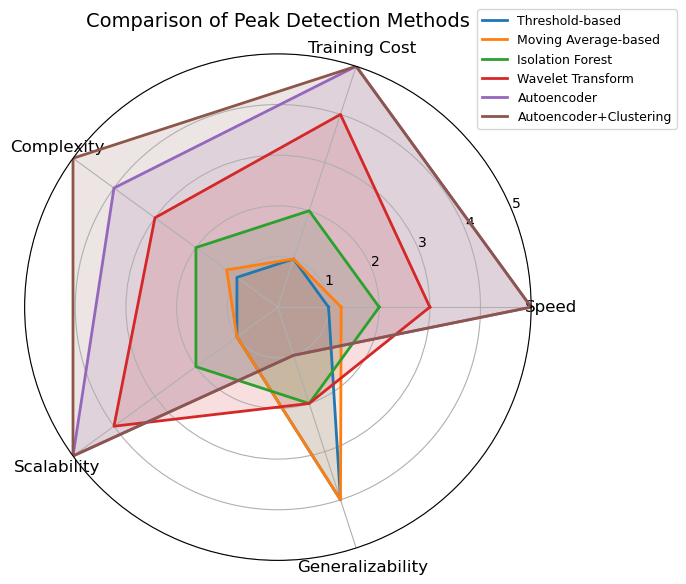

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["Threshold-based", "Moving Average-based", "Isolation Forest", "Wavelet Transform", "Autoencoder", "Autoencoder+Clustering"]

# relative scores (1=low, 5=high cost/complexity)
speed = [1, 1.25, 2, 3, 5, 5]            # threshold is fastest, autoencoder slowest
train_cost = [1, 1, 2, 4, 5, 5]       # autoencoder (+ clustering) and wavelet transform has heavy training cost
complexity = [1, 1.25, 2, 3, 4, 5]       # threshold simplest, autoencoder most complex
scalability = [1, 1, 2, 4, 5, 5]      # threshold + MA scale better. 
generalizability = [4, 4, 2, 2, 1, 1] # Autoencoder based methods are more generalizable 

categories = ["Speed", "Training Cost", "Complexity", "Scalability", "Generalizability"]
data = np.array([speed, train_cost, complexity, scalability, generalizability]).T

N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, method in enumerate(methods):
    values = data[i].tolist()
    values += values[:1]
    ax.plot(angles, values, label=method, linewidth=2)
    ax.fill(angles, values, alpha=0.15)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=10)
ax.set_ylim(0, 5)

plt.title("Comparison of Peak Detection Methods", fontsize=14, pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

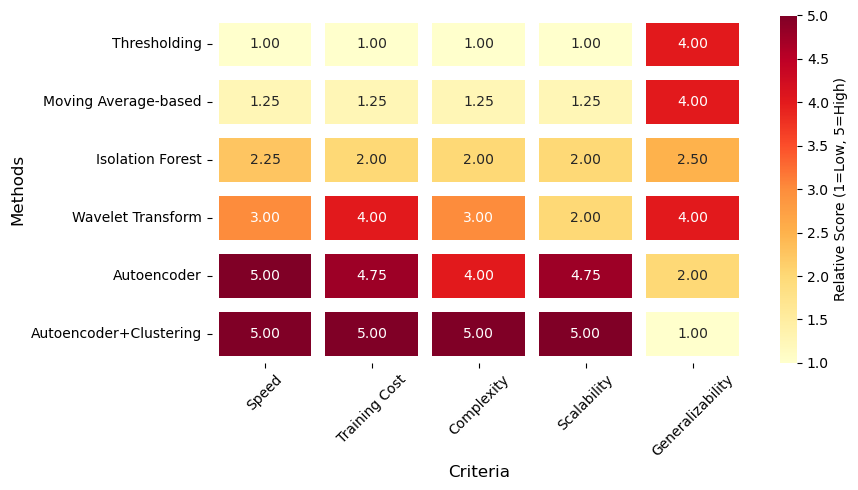

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

methods = ["Threshold-based", "Moving Average-based", "Isolation Forest", "Wavelet Transform", "Autoencoder", "Autoencoder+Clustering"]


# Data (1 = best / lowest , 5 = worst / highest )
data = {
    "Thresholding":     [1, 1, 1, 1, 4],                    # very fast, minimal training, simple, scales well but not generalizable
    "Moving Average-based": [1.25, 1.25, 1.25, 1.25, 4],    #similar to thresholding. 
    "Isolation Forest": [2.25, 2, 2, 2, 2.5],               # moderate 
    "Wavelet Transform":[3, 4, 3, 2, 4],                    # moderately fast, some complexity, good scalability
    "Autoencoder":      [5, 4.75, 4, 4.75, 2],              # slow, expensive training, complex, limited scalability
    "Autoencoder+Clustering": [5, 5, 5, 5, 1]               # slow, expensive training, complex, limited scalability
}

criteria = ["Speed", "Training Cost", "Complexity", "Scalability", "Generalizability"]

df = pd.DataFrame(data, index=criteria).T

plt.figure(figsize=(9,5))
sns.heatmap(
    df, annot=True, cmap="YlOrRd",
    cbar_kws={'label': 'Relative Score (1=Low, 5=High)'},
    linewidths=10, linecolor="white",  
    fmt=".2f"  
)

# plt.title("Computational Cost and Complexity of Peak Detection Methods", fontsize=14, pad=15)
plt.ylabel("Methods", fontsize=12)
plt.xlabel("Criteria", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()